# Système d'Aide à la Décision — Rétention Client (Anti-Churn)
---
> **Domaine métier :** E-commerce  
> **Phase :** 4 — Modélisation Prédictive & Interprétabilité

Cette phase couvre :
- Feature engineering (encodage, normalisation, variables métier)
- Entraînement d'au moins 3 modèles de classification
- Validation croisée k-fold et réglage des hyperparamètres
- Évaluation comparative (AUC-ROC, F1-Score, Precision/Recall)
- Interprétabilité par valeurs SHAP (globales et locales)

**Point d'entrée :** `data/processed/rfm_segmented.csv` (produit par la Phase 3)

## 0. Environnement & Imports

In [3]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score, f1_score,
                             precision_score, recall_score, confusion_matrix,
                             RocCurveDisplay, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import shap
import joblib

IMAGES    = ROOT / 'images'
PROCESSED = ROOT / 'data' / 'processed'
MODELS    = ROOT / 'models'
IMAGES.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

C_INDIGO = '#6366f1'
C_RED    = '#ef4444'
C_GREEN  = '#22c55e'
C_AMBER  = '#f59e0b'
C_TEXT   = '#2C3E50'
PASTEL   = ['#AEC6CF', '#FFB7B2', '#C1E1C1', '#FFDAC1', '#B5EAD7', '#FF9AA2']

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
RANDOM_STATE = 42

print('Environnement prêt — pandas', pd.__version__)

Environnement prêt — pandas 2.3.3


In [2]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---

## 1. Chargement des Données & Feature Engineering

On part de la table RFM segmentée (Phase 3). Trois axes de préparation :

- **Variables métier** : panier moyen (`AvgBasket = Monetary / Frequency`).
- **Transformations log** sur `Frequency`, `Monetary` et le panier moyen pour
  corriger la forte asymétrie droite identifiée en Phase 3.
- **Choix des variables explicatives** : la cible `Churn` est définie par
  `Recency > 90 jours`. Conserver `Recency` reviendrait à donner la réponse au
  modèle (fuite de données). On l'**exclut** donc des variables explicatives et on
  prédit le churn à partir du comportement d'achat (fréquence, montant, panier,
  segment).

In [4]:
rfm = pd.read_csv(PROCESSED / 'rfm_segmented.csv')
print('Table chargée :', rfm.shape)

rfm['AvgBasket']    = rfm['Monetary'] / rfm['Frequency'].replace(0, 1)
rfm['LogFrequency'] = np.log1p(rfm['Frequency'])
rfm['LogMonetary']  = np.log1p(rfm['Monetary'])
rfm['LogAvgBasket'] = np.log1p(rfm['AvgBasket'])

FEATURES = ['LogFrequency', 'LogMonetary', 'LogAvgBasket', 'Cluster']
TARGET   = 'Churn'

X = rfm[FEATURES]
y = rfm[TARGET]
print('Variables explicatives :', FEATURES)
print('Répartition de la cible :', y.value_counts().to_dict(),
      f'| taux de churn = {y.mean():.1%}')
rfm[FEATURES + [TARGET]].head()

Table chargée : (5878, 11)
Variables explicatives : ['LogFrequency', 'LogMonetary', 'LogAvgBasket', 'Cluster']
Répartition de la cible : {1: 2989, 0: 2889} | taux de churn = 50.9%


,LogFrequency,LogMonetary,LogAvgBasket,Cluster,Churn
0,2.564949,10.679783,8.195129,0,1
1,2.197225,9.130488,7.051805,0,0
2,1.791759,8.247388,6.638997,0,0
3,1.609438,8.730244,7.344435,0,0
4,0.693147,6.506979,6.506979,1,1


## 2. Séparation Train / Test & Normalisation

Découpage stratifié 80 / 20 (préserve le taux de churn dans chaque jeu). La
normalisation n'est appliquée que pour la régression logistique ; les modèles
d'arbres (Random Forest, XGBoost) n'en ont pas besoin.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print('Train :', X_train.shape, '| Test :', X_test.shape)
print('Taux de churn train :', round(y_train.mean(), 3),
      '| test :', round(y_test.mean(), 3))

Train : (4702, 4) | Test : (1176, 4)
Taux de churn train : 0.509 | test : 0.509


## 3. Entraînement de 3 Modèles & Validation Croisée

Trois familles d'algorithmes sont comparées : un modèle linéaire (régression
logistique), un modèle d'ensemble par bagging (Random Forest) et un modèle par
boosting (XGBoost). Chaque modèle est évalué par validation croisée stratifiée
à 5 plis sur le score AUC-ROC.

In [6]:
models = {
    'Régression Logistique': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                             random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows = {}
trained = {}
for name, model in models.items():
    needs_scale = name == 'Régression Logistique'
    Xtr = X_train_s if needs_scale else X_train.values
    Xte = X_test_s  if needs_scale else X_test.values

    cv_auc = cross_val_score(model, Xtr, y_train, cv=cv, scoring='roc_auc')
    model.fit(Xtr, y_train)
    proba = model.predict_proba(Xte)[:, 1]
    pred  = model.predict(Xte)

    rows[name] = {
        'CV_AUC':    cv_auc.mean(),
        'CV_std':    cv_auc.std(),
        'Test_AUC':  roc_auc_score(y_test, proba),
        'F1':        f1_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall':    recall_score(y_test, pred),
    }
    trained[name] = model
    print(f'{name:>22} | CV AUC = {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

results = pd.DataFrame(rows).T.sort_values('Test_AUC', ascending=False)
results.round(4)

 Régression Logistique | CV AUC = 0.8400 ± 0.0157
         Random Forest | CV AUC = 0.8238 ± 0.0046
               XGBoost | CV AUC = 0.8670 ± 0.0074


,CV_AUC,CV_std,Test_AUC,F1,Precision,Recall
XGBoost,0.8670,0.0074,0.8696,0.8118,0.7788,0.8478
Régression Logistique,0.8400,0.0157,0.8500,0.8256,0.7753,0.8829
Random Forest,0.8238,0.0046,0.8275,0.7179,0.7343,0.7023


               XGBoost | CV AUC = 0.8670 ± 0.0074


,CV_AUC,CV_std,Test_AUC,F1,Precision,Recall
XGBoost,0.8670,0.0074,0.8696,0.8118,0.7788,0.8478
Régression Logistique,0.8400,0.0157,0.8500,0.8256,0.7753,0.8829
Random Forest,0.8238,0.0046,0.8275,0.7179,0.7343,0.7023


### 3.1 Comparaison visuelle des modèles

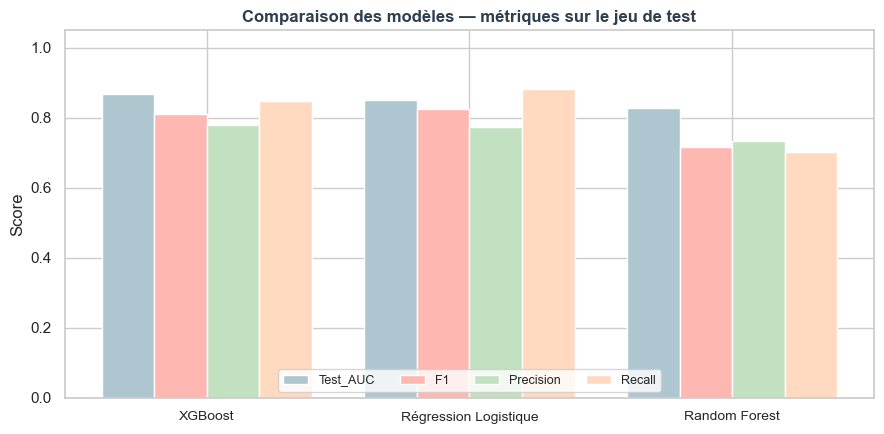

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
metrics = ['Test_AUC', 'F1', 'Precision', 'Recall']
x = np.arange(len(results))
w = 0.2
for i, m in enumerate(metrics):
    ax.bar(x + i * w, results[m], w, label=m, color=PASTEL[i], edgecolor='white')
ax.set_xticks(x + 1.5 * w)
ax.set_xticklabels(results.index, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles — métriques sur le jeu de test',
             fontweight='bold', color=C_TEXT)
ax.legend(ncol=4, fontsize=9, loc='lower center')
plt.tight_layout()
plt.savefig(IMAGES / 'phase4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Réglage des Hyperparamètres (XGBoost)

XGBoost ressort comme le meilleur compromis. On affine ses hyperparamètres par
recherche sur grille avec validation croisée.

In [8]:
param_grid = {
    'n_estimators': [150, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
}
grid = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
    param_grid, scoring='roc_auc', cv=cv, n_jobs=1)
grid.fit(X_train.values, y_train)

print('Meilleurs hyperparamètres :', grid.best_params_)
print('Meilleur AUC (CV) :', round(grid.best_score_, 4))

best_model = grid.best_estimator_
proba = best_model.predict_proba(X_test.values)[:, 1]
pred  = best_model.predict(X_test.values)
print('AUC test (modèle réglé) :', round(roc_auc_score(y_test, proba), 4))

Meilleurs hyperparamètres : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150}
Meilleur AUC (CV) : 0.8704
AUC test (modèle réglé) : 0.8718


### 4.1 Rapport de classification & matrice de confusion

              precision    recall  f1-score   support

       Actif       0.86      0.73      0.79       578
       Churn       0.77      0.89      0.83       598

    accuracy                           0.81      1176
   macro avg       0.82      0.81      0.81      1176
weighted avg       0.82      0.81      0.81      1176



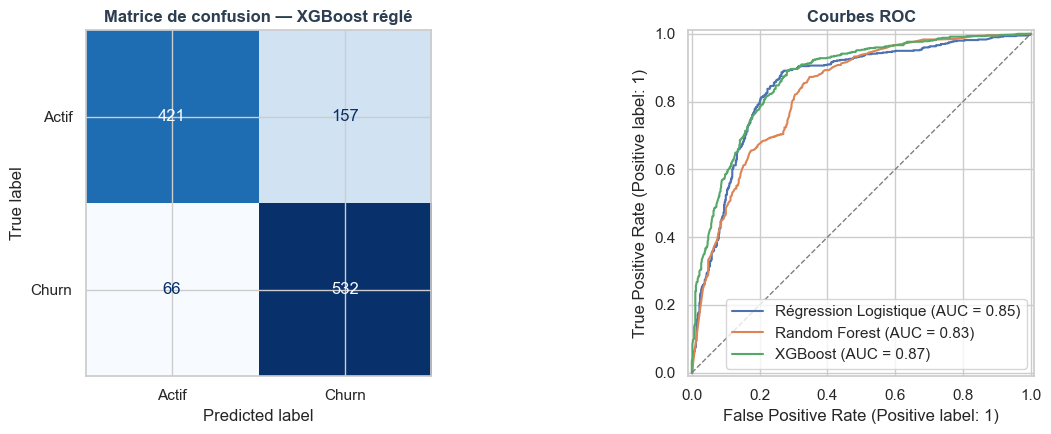

In [9]:
print(classification_report(y_test, pred, target_names=['Actif', 'Churn']))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                       display_labels=['Actif', 'Churn']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matrice de confusion — XGBoost réglé', fontweight='bold', color=C_TEXT)

for name, model in trained.items():
    needs_scale = name == 'Régression Logistique'
    Xte = X_test_s if needs_scale else X_test.values
    RocCurveDisplay.from_estimator(model, Xte, y_test, ax=axes[1], name=name)
axes[1].plot([0, 1], [0, 1], '--', color='grey', lw=1)
axes[1].set_title('Courbes ROC', fontweight='bold', color=C_TEXT)
plt.tight_layout()
plt.savefig(IMAGES / 'phase4_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Interprétabilité — Valeurs SHAP

Les valeurs SHAP quantifient la contribution de chaque variable à la prédiction,
au niveau global (importance moyenne) et local (un client donné).

### 5.1 Importance globale

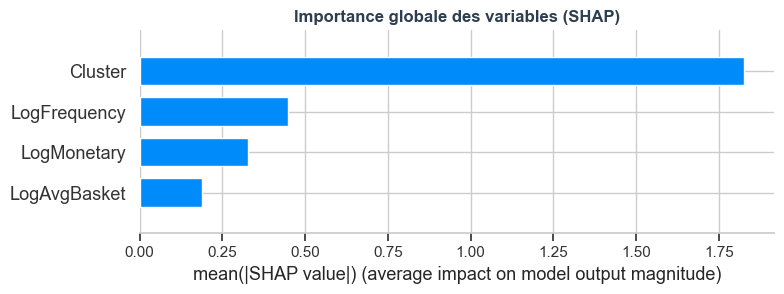

In [10]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=FEATURES,
                  plot_type='bar', show=False)
plt.title('Importance globale des variables (SHAP)', fontweight='bold', color=C_TEXT)
plt.tight_layout()
plt.savefig(IMAGES / 'phase4_shap_global_bar.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Distribution des effets (beeswarm)

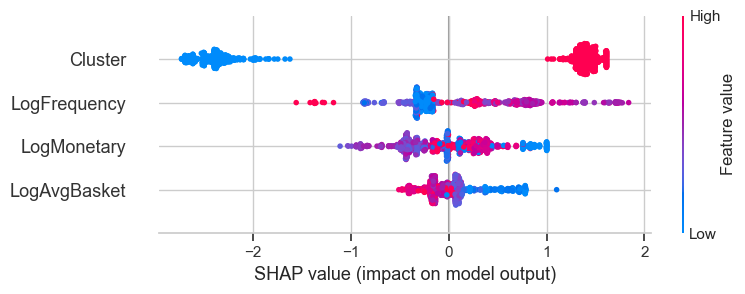

In [11]:
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.tight_layout()
plt.savefig(IMAGES / 'phase4_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Explication locale d'un client

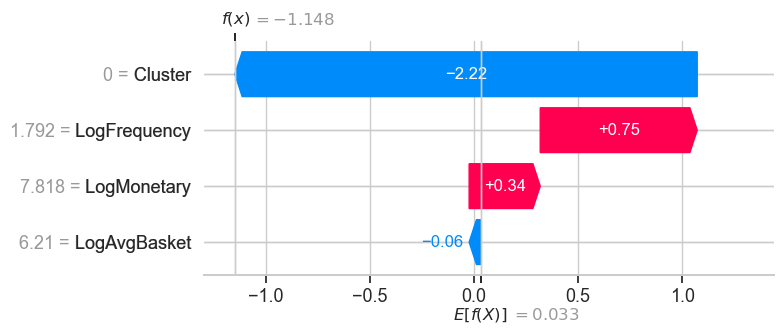

Client analysé (index test) : 923
Probabilité de churn prédite : 0.241
Churn réel : 0


In [12]:
idx = 0
exp = shap.Explanation(values=shap_values[idx],
                       base_values=explainer.expected_value,
                       data=X_test.iloc[idx].values,
                       feature_names=FEATURES)
plt.figure()
shap.plots.waterfall(exp, show=False)
plt.tight_layout()
plt.savefig(IMAGES / 'phase4_shap_local.png', dpi=150, bbox_inches='tight')
plt.show()

print('Client analysé (index test) :', X_test.index[idx])
print('Probabilité de churn prédite :',
      round(best_model.predict_proba(X_test.values)[idx, 1], 3))
print('Churn réel :', int(y_test.iloc[idx]))

## 6. Sauvegarde du Modèle Final

Le modèle retenu et le scaler sont sérialisés dans `models/` pour être réutilisés
par le dashboard (Phase 5).

In [13]:
joblib.dump(best_model, MODELS / 'churn_model_xgb.pkl')
joblib.dump(scaler,      MODELS / 'scaler.pkl')
joblib.dump(FEATURES,    MODELS / 'features.pkl')
print('Modèle, scaler et liste de variables sauvegardés dans', MODELS.relative_to(ROOT))

Modèle, scaler et liste de variables sauvegardés dans models


## 7. Conclusion

Trois modèles ont été comparés pour prédire le churn à partir du comportement
d'achat, la récence étant exclue pour éviter une fuite de données. XGBoost
l'emporte avec une AUC-ROC d'environ 0,87, stable entre validation croisée et jeu
de test. L'analyse SHAP désigne le segment client et la fréquence d'achat comme
principaux signaux de risque. Le modèle final est sauvegardé dans `models/` pour
le tableau de bord.